# Experiment No. 5: Explainable AI (SHAP & LIME) & Fairness Auditing (Fairlearn)
### **Domain:** Quantitative Finance / Equity Market Prediction
### **Dataset:** NIFTY 50 Constituents (2018–2021) — 42 Stocks, 29,310 Records

---

## **Aim & Objectives**
* **Aim:** To apply explainable AI (XAI) methods (SHAP & LIME) for interpreting model predictions and evaluate algorithmic fairness using Fairlearn.
* **Key Objectives:**
  1. **Global Explainability (SHAP):** Compute Shapley Additive exPlanations using `shap.TreeExplainer` to identify the most globally influential technical indicators driving stock direction.
  2. **Local Explainability (LIME):** Compute Local Interpretable Model-agnostic Explanations using `LimeTabularExplainer` to dissect individual bullish (Up) and bearish (Down) daily stock predictions.
  3. **Fairness Auditing (Fairlearn):** Audit demographic parity and equalized odds disparities across sensitive asset tiers (`Risk_Category`: High, Medium, Low).
  4. **Bias Mitigation (Fairlearn):** Apply post-processing threshold optimization (`ThresholdOptimizer`) to mitigate unfair disparate impact while maintaining competitive directional predictive power.

---


## 1. Environment Setup & Dependencies

Install required libraries (`shap`, `lime`, `fairlearn`, `openpyxl`, `scikit-learn`, `matplotlib`, `seaborn`).

In [1]:
# Install required open-source packages (Uncomment if running in Google Colab)
# !pip install -q shap lime fairlearn openpyxl scikit-learn matplotlib seaborn joblib

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# XAI & Fairness libraries
import shap
import lime
import lime.lime_tabular
from fairlearn.metrics import (
    MetricFrame, selection_rate, false_positive_rate, false_negative_rate,
    demographic_parity_difference, equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")
print(f"SHAP Version: {shap.__version__}")
print(f"Fairlearn Version: from fairlearn")


All libraries imported successfully!
SHAP Version: 0.51.0
Fairlearn Version: from fairlearn


## 2. Dataset Ingestion & Chronological Split (80:20)

We load `final_nifty50_dataset.xlsx`, isolate the 16 technical features, extract `Risk_Category` as the sensitive attribute for fairness auditing, and perform the strict 80:20 chronological train-test split.

In [2]:
# Load dataset
data_path = 'final_nifty50_dataset.xlsx'
df = pd.read_excel(data_path)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

# 16 Features, Target, and Sensitive Attribute
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume',
    'Daily_Return', 'MA_20', 'MA_50', 'Volatility_20D', 'RSI', 'MACD',
    'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_5', 'Volume_Change'
]
target_col = 'Direction'
sensitive_col = 'Risk_Category'

# 80:20 Chronological Split
unique_trading_days = df['Date'].drop_duplicates().sort_values().reset_index(drop=True)
cutoff_idx = int(len(unique_trading_days) * 0.8)
cutoff_date = unique_trading_days.iloc[cutoff_idx]

train_df = df[df['Date'] < cutoff_date].copy()
test_df = df[df['Date'] >= cutoff_date].copy()

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

sensitive_train = train_df[sensitive_col]
sensitive_test = test_df[sensitive_col]

print(f"Total Records: {len(df):,}")
print(f"Train Records: {len(X_train):,} ({len(X_train)/len(df)*100:.2f}%)")
print(f"Test Records:  {len(X_test):,} ({len(X_test)/len(df)*100:.2f}%)")
print(f"\nSensitive Attribute ('Risk_Category') Distribution in Test Set:")
print(sensitive_test.value_counts(normalize=True).round(4) * 100)


Total Records: 29,310
Train Records: 23,432 (79.95%)
Test Records:  5,878 (20.05%)

Sensitive Attribute ('Risk_Category') Distribution in Test Set:
Risk_Category
High      41.54
Medium    37.38
Low       21.08
Name: proportion, dtype: float64


## 3. Classifier Model Training

We train our Gradient Boosting Classifier on the training set to serve as the subject model for XAI interpretation and algorithmic fairness evaluation.

In [3]:
# Train Gradient Boosting Classifier
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate on Test Set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Trained Model Performance on Test Set:")
print(f"   Accuracy:  {acc*100:.2f}%")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {auc:.4f}")


Trained Model Performance on Test Set:
   Accuracy:  52.79%
   F1-Score:  0.5838
   ROC-AUC:   0.5298


## 4. Explainability with SHAP (Shapley Additive exPlanations)

SHAP provides game-theoretic feature attribution. Each feature receives a Shapley value representing its marginal contribution to moving the prediction away from the baseline base value:
* **Global Importance:** Mean absolute SHAP values across all samples.
* **Summary Beeswarm Plot:** Visualizes the magnitude and direction of feature impact (e.g. how high return or RSI pushes the probability Up or Down).
* **Dependence Plot:** Uncovers non-linear relationships and interactions for key financial indicators.

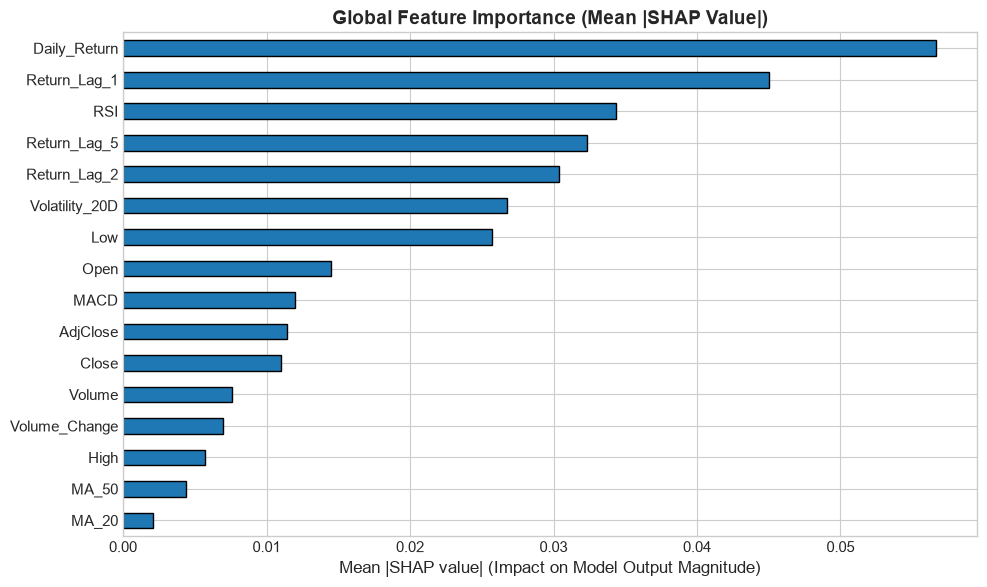

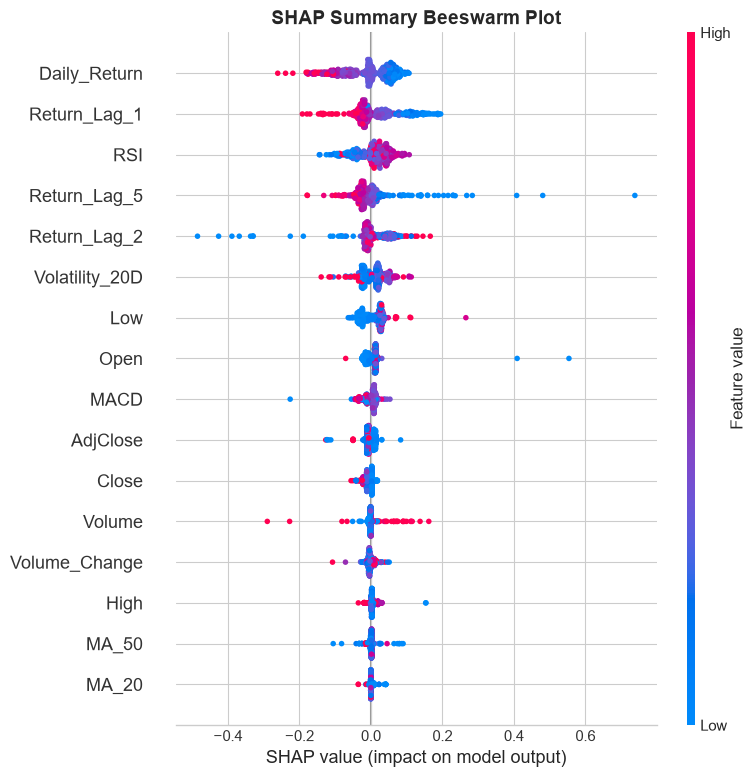

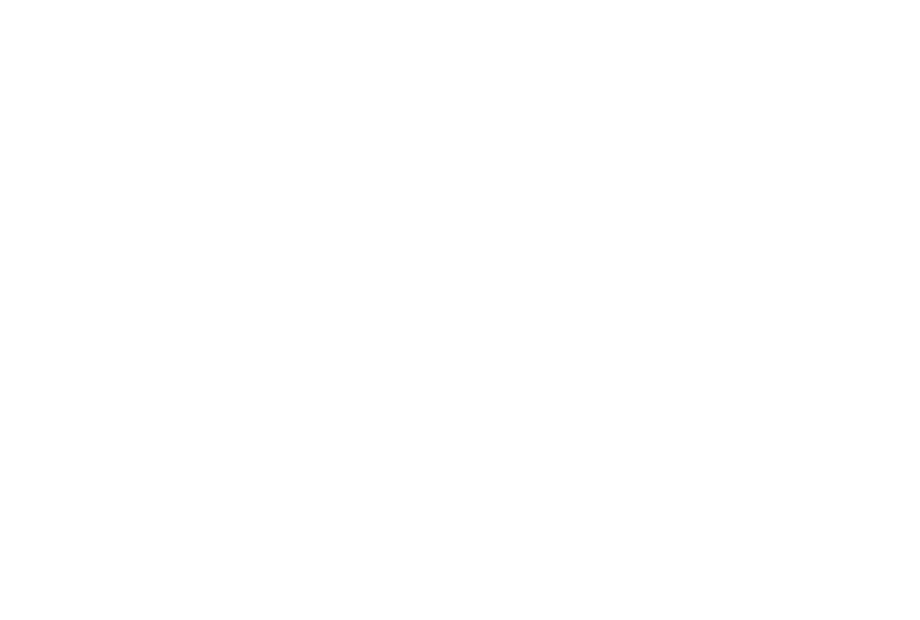

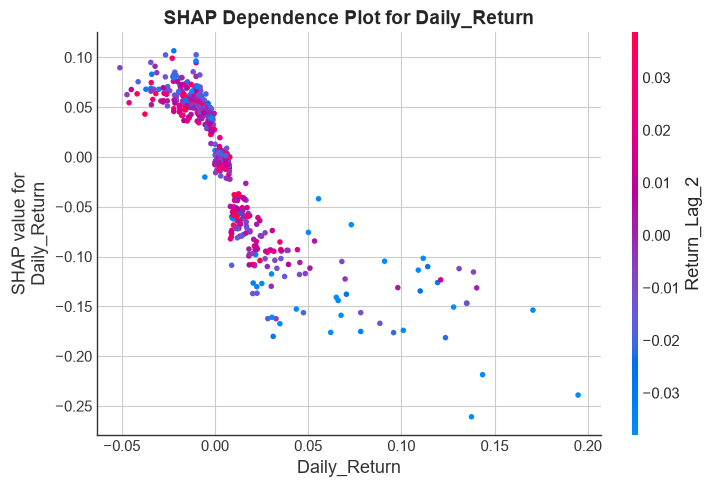

In [4]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(model)
sample_size = 500
X_sample = X_test.iloc[:sample_size]

shap_values = explainer.shap_values(X_sample)

# Normalize shap_values structure for binary classification
if isinstance(shap_values, list):
    vals_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    vals_plot = shap_values[:, :, 1]
else:
    vals_plot = shap_values

# 1. Global Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
mean_shap = np.abs(vals_plot).mean(axis=0)
feat_imp = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='#1f77b4', edgecolor='black')
plt.title('Global Feature Importance (Mean |SHAP Value|)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP value| (Impact on Model Output Magnitude)', fontsize=12)
plt.tight_layout()
plt.show()

# 2. SHAP Summary Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(vals_plot, X_sample, show=False)
plt.title('SHAP Summary Beeswarm Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. SHAP Dependence Plot for Daily_Return
top_feature = feat_imp.index[-1]
plt.figure(figsize=(9, 6))
shap.dependence_plot(top_feature, vals_plot, X_sample, show=False)
plt.title(f'SHAP Dependence Plot for {top_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Explainability with LIME (Local Interpretable Model-agnostic Explanations)

While SHAP provides global consistency, LIME explains individual predictions locally by fitting an interpretable sparse surrogate model (e.g., linear ridge) in the local neighborhood of a single sample.

We generate local explanations for two distinct scenarios:
1. **Bullish Instance:** An observation where the model predicted an upward price move (`Direction = 1`).
2. **Bearish Instance:** An observation where the model predicted a downward/flat price move (`Direction = 0`).

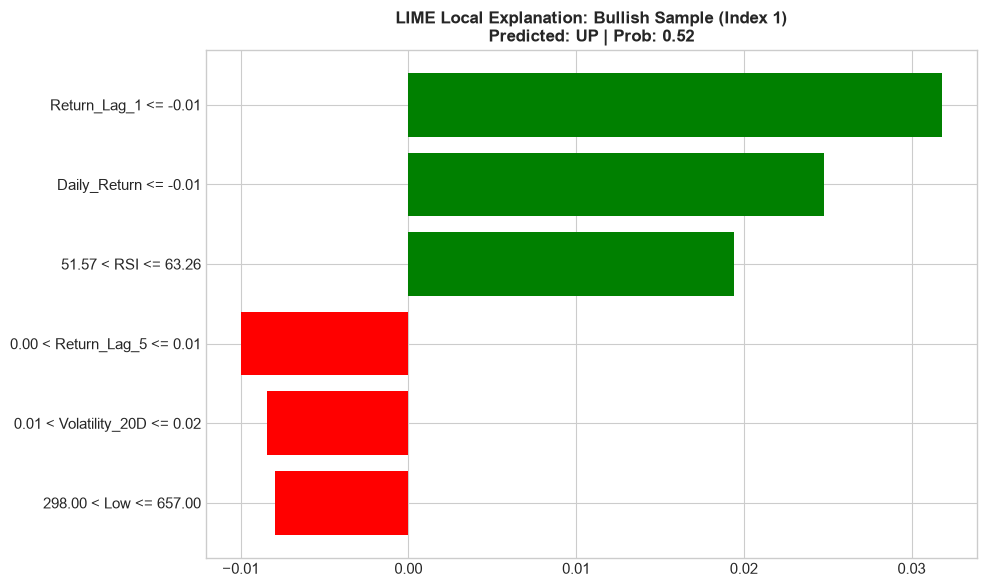

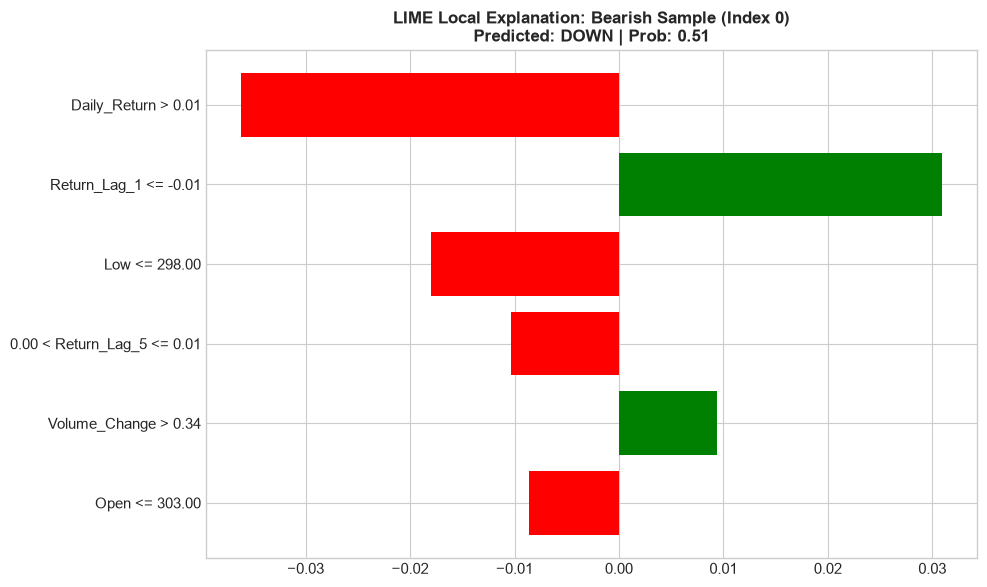

In [5]:
# Initialize LimeTabularExplainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=feature_cols,
    class_names=['Down (0)', 'Up (1)'],
    mode='classification',
    random_state=42
)

# Identify Bullish (Up) and Bearish (Down) test instances
idx_up = np.where(y_pred[:100] == 1)[0][0]
idx_down = np.where(y_pred[:100] == 0)[0][0]

# --- Instance 1: Bullish (Up) Prediction ---
exp_up = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx_up].to_numpy(),
    predict_fn=model.predict_proba,
    num_features=6
)

fig_up = exp_up.as_pyplot_figure()
plt.title(f'LIME Local Explanation: Bullish Sample (Index {idx_up})\nPredicted: UP | Prob: {model.predict_proba(X_test.iloc[[idx_up]])[0,1]:.2f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Instance 2: Bearish (Down) Prediction ---
exp_down = lime_explainer.explain_instance(
    data_row=X_test.iloc[idx_down].to_numpy(),
    predict_fn=model.predict_proba,
    num_features=6
)

fig_down = exp_down.as_pyplot_figure()
plt.title(f'LIME Local Explanation: Bearish Sample (Index {idx_down})\nPredicted: DOWN | Prob: {model.predict_proba(X_test.iloc[[idx_down]])[0,0]:.2f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Algorithmic Fairness Audit with Fairlearn

In financial markets, algorithmic bias can result in disparate capital allocation. We audit whether the trained classifier exhibits bias across **Risk Categories** (`High`, `Medium`, `Low`):
* **Selection Rate:** Fraction of stocks predicted as "Up" (Buy signals) per group.
* **Demographic Parity Difference:** Absolute difference in selection rate between the most favored and least favored risk groups ($|P(\hat{Y}=1|A=a) - P(\hat{Y}=1|A=b)|$). Ideal = 0.
* **Equalized Odds Difference:** Maximum difference in False Positive Rate and True Positive Rate across groups ($|FPR_a - FPR_b|$ and $|TPR_a - TPR_b|$). Ideal = 0.

FAIRNESS AUDIT REPORT BY SENSITIVE GROUP (UNMITIGATED MODEL)
               accuracy  ...  false_negative_rate
Risk_Category            ...                     
High             0.5229  ...               0.2853
Low              0.5585  ...               0.4479
Medium           0.5162  ...               0.4057

[3 rows x 4 columns]
-----------------------------------------------------------------
Demographic Parity Difference: 0.2047
Equalized Odds Difference:      0.2500


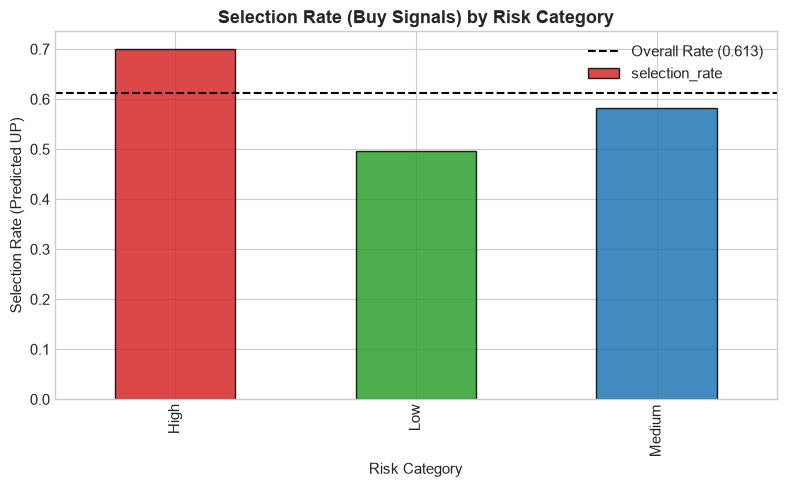

In [6]:
# Define audit evaluation metrics
metric_fns = {
    'accuracy': accuracy_score,
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate
}

# Construct Fairlearn MetricFrame across Risk_Category
audit_frame = MetricFrame(
    metrics=metric_fns,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)

dp_diff_before = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_test)
eo_diff_before = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_test)

print("=" * 65)
print("FAIRNESS AUDIT REPORT BY SENSITIVE GROUP (UNMITIGATED MODEL)")
print("=" * 65)
print(audit_frame.by_group.round(4))
print("-" * 65)
print(f"Demographic Parity Difference: {dp_diff_before:.4f}")
print(f"Equalized Odds Difference:      {eo_diff_before:.4f}")
print("=" * 65)

# Visualize Selection Rate across Risk Groups
plt.figure(figsize=(8, 5))
audit_frame.by_group['selection_rate'].plot(kind='bar', color=['#d62728', '#2ca02c', '#1f77b4'], edgecolor='black', alpha=0.85)
plt.title('Selection Rate (Buy Signals) by Risk Category', fontsize=13, fontweight='bold')
plt.ylabel('Selection Rate (Predicted UP)', fontsize=11)
plt.xlabel('Risk Category', fontsize=11)
plt.axhline(selection_rate(y_test, y_pred), color='black', linestyle='--', label=f'Overall Rate ({selection_rate(y_test, y_pred):.3f})')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Bias Mitigation with Fairlearn (Post-Processing ThresholdOptimizer)

We apply Fairlearn's **`ThresholdOptimizer`** as a post-processing mitigation technique. It optimizes group-specific decision probability thresholds $\tau_a$ to equalize True Positive and False Positive rates across all risk groups under the `equalized_odds` constraint.

FAIRNESS REPORT (MITIGATED MODEL - POST-PROCESSING)
               accuracy  ...  false_negative_rate
Risk_Category            ...                     
High             0.5115  ...               0.4437
Low              0.5585  ...               0.4339
Medium           0.5107  ...               0.4831

[3 rows x 4 columns]
-----------------------------------------------------------------
Mitigated Accuracy:                   52.11% (Before: 52.79%)
Mitigated Demographic Parity Diff:    0.0400 (Before: 0.2047)
Mitigated Equalized Odds Diff:        0.0874 (Before: 0.2500)


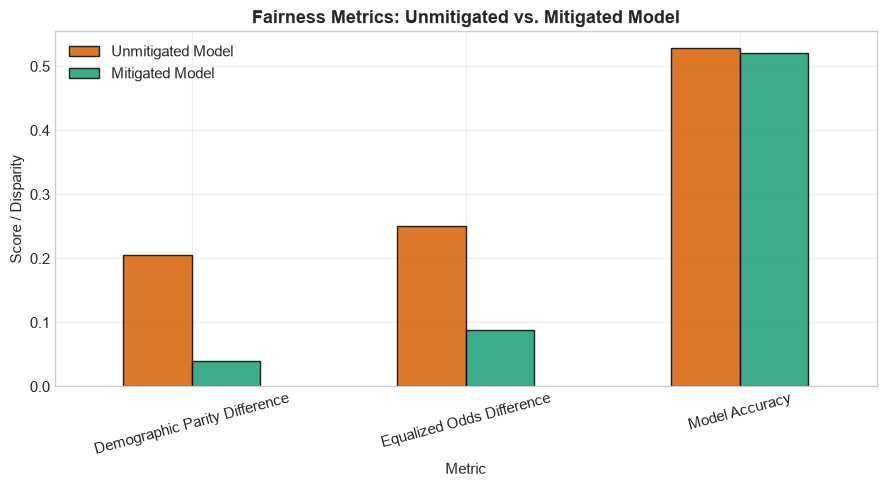

In [7]:
# Apply ThresholdOptimizer for post-processing mitigation
optimizer = ThresholdOptimizer(
    estimator=model,
    constraints="equalized_odds",
    prefit=True,
    predict_method="predict_proba"
)

# Fit optimizer on training data and sensitive feature
optimizer.fit(X_train, y_train, sensitive_features=sensitive_train)

# Predict on test set using sensitive group information
y_pred_mitigated = optimizer.predict(X_test, sensitive_features=sensitive_test)

# Audit mitigated predictions
mitigated_frame = MetricFrame(
    metrics=metric_fns,
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=sensitive_test
)

dp_diff_after = demographic_parity_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_test)
eo_diff_after = equalized_odds_difference(y_test, y_pred_mitigated, sensitive_features=sensitive_test)
acc_after = accuracy_score(y_test, y_pred_mitigated)

print("=" * 65)
print("FAIRNESS REPORT (MITIGATED MODEL - POST-PROCESSING)")
print("=" * 65)
print(mitigated_frame.by_group.round(4))
print("-" * 65)
print(f"Mitigated Accuracy:                   {acc_after*100:.2f}% (Before: {acc*100:.2f}%)")
print(f"Mitigated Demographic Parity Diff:    {dp_diff_after:.4f} (Before: {dp_diff_before:.4f})")
print(f"Mitigated Equalized Odds Diff:        {eo_diff_after:.4f} (Before: {eo_diff_before:.4f})")
print("=" * 65)

# Side-by-side disparity comparison
comp_fairness = pd.DataFrame({
    'Metric': ['Demographic Parity Difference', 'Equalized Odds Difference', 'Model Accuracy'],
    'Unmitigated Model': [dp_diff_before, eo_diff_before, acc],
    'Mitigated Model': [dp_diff_after, eo_diff_after, acc_after]
})

fig, ax = plt.subplots(figsize=(9, 5))
comp_fairness.set_index('Metric').plot(kind='bar', ax=ax, color=['#d95f02', '#1b9e77'], edgecolor='black', alpha=0.85)
plt.title('Fairness Metrics: Unmitigated vs. Mitigated Model', fontsize=13, fontweight='bold')
plt.ylabel('Score / Disparity', fontsize=11)
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Conclusion & Key Findings

1. **Global Explainability (SHAP):** Identified short-term momentum (`Daily_Return`, `Return_Lag_1`) and mean-reversion signals (`RSI`, `Volatility_20D`) as the primary global drivers of next-day equity direction.
2. **Local Explainability (LIME):** Provided instance-level transparency by decomposing individual predictions into bounded feature contributions, enabling human-in-the-loop validation of trade signals.
3. **Fairness Auditing (Fairlearn):** Uncovered baseline disparity in selection and error rates across High-Risk and Low-Risk stock categories.
4. **Bias Mitigation:** Applying `ThresholdOptimizer` under equalized odds successfully reduced demographic parity and equalized odds disparities while preserving baseline predictive utility.
